# Neurology Multiple-Choice Question Analysis

This notebook analyses model responses to 100 neurology multiple-choice
questions and generates the study figures, main table, and supplementary
accuracy table. It expects `master_collated_analysis.csv` to be present in the
same directory as the notebook.



## 1. Setup



In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(pROC)
  library(knitr)
  library(ggrepel)
})

theme_pub <- theme_minimal(base_size = 11, base_family = "sans") +
  theme(
    panel.grid.major = element_line(colour = "grey92", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(colour = "grey70", fill = NA, linewidth = 0.4),
    strip.background = element_rect(fill = "grey96", colour = "grey70", linewidth = 0.4),
    strip.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 13, margin = margin(b = 4)),
    plot.subtitle = element_text(size = 9.5, colour = "grey35", margin = margin(b = 8)),
    legend.key.size = unit(0.45, "cm"),
    plot.margin = margin(10, 12, 10, 12)
  )
theme_set(theme_pub)

input_path <- "master_collated_analysis.csv"
output_dir <- "github_outputs"
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)



Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘knitr’ was built under R version 4.3.3”


## 2. Model and Method Definitions



In [2]:
model_order <- c(
  "meta-llama_llama-3.1-8b-instruct",
  "meta-llama_llama-3.1-70b-instruct",
  "meta-llama_llama-3.1-405b-instruct",
  "deepseek_deepseek-v3.2",
  "openai_gpt-4o",
  "moonshotai_kimi-k2.5",
  "google_gemini-3-flash-preview",
  "google_gemini-3-pro-preview"
)

model_labels <- c(
  "meta-llama_llama-3.1-8b-instruct" = "LLaMA 8B",
  "meta-llama_llama-3.1-70b-instruct" = "LLaMA 70B",
  "meta-llama_llama-3.1-405b-instruct" = "LLaMA 405B",
  "deepseek_deepseek-v3.2" = "DeepSeek v3.2",
  "openai_gpt-4o" = "GPT-4o",
  "moonshotai_kimi-k2.5" = "Kimi K2.5",
  "google_gemini-3-flash-preview" = "Gemini 3 Flash",
  "google_gemini-3-pro-preview" = "Gemini 3 Pro"
)

model_colours <- c(
  "meta-llama_llama-3.1-8b-instruct" = "#F4A582",
  "meta-llama_llama-3.1-70b-instruct" = "#D6604D",
  "meta-llama_llama-3.1-405b-instruct" = "#B2182B",
  "deepseek_deepseek-v3.2" = "#4DAF4A",
  "openai_gpt-4o" = "#984EA3",
  "moonshotai_kimi-k2.5" = "#377EB8",
  "google_gemini-3-flash-preview" = "#FF7F00",
  "google_gemini-3-pro-preview" = "#E6AB02"
)

model_label_colours <- setNames(model_colours[model_order], model_labels[model_order])

confidence_methods <- c(
  "Self-Reported" = "confidence_model_deterministic",
  "Critique-Implied" = "confidence_critic_deterministic",
  "Consistency" = "consistency_confidence_in_deterministic_answer"
)



## 3. Load and Prepare the Dataset



In [3]:
df <- read_csv(input_path, show_col_types = FALSE) |>
  mutate(
    model = factor(model, levels = model_order),
    model_label = factor(model_labels[as.character(model)], levels = model_labels[model_order]),
    correct_deterministic = tolower(model_answer_deterministic) == tolower(gold_answer),
    correct_consistency = tolower(model_favoured_answer_consistency_including_tiebreaks) == tolower(gold_answer),
    QuType = factor(QuType, levels = c("text", "image"))
  )

stopifnot(nrow(df) == 800)
stopifnot(n_distinct(df$model) == length(model_order))
stopifnot(n_distinct(df$question_id) == 100)
stopifnot(!any(is.na(df$confidence_model_deterministic)))
stopifnot(!any(is.na(df$confidence_critic_deterministic)))
stopifnot(!any(is.na(df$consistency_confidence_in_deterministic_answer)))

data_summary <- tibble(
  rows = nrow(df),
  models = n_distinct(df$model),
  questions = n_distinct(df$question_id),
  text_questions = sum(df$QuType == "text") / n_distinct(df$model),
  image_questions = sum(df$QuType == "image") / n_distinct(df$model)
)

write_csv(data_summary, file.path(output_dir, "data_summary.csv"))
data_summary



rows,models,questions,text_questions,image_questions
<int>,<int>,<int>,<dbl>,<dbl>
800,8,100,93,7


## 4. Analysis Functions



In [4]:
fmt_acc_ci <- function(n_correct, n_total) {
  ci <- suppressWarnings(binom.test(n_correct, n_total)$conf.int * 100)
  acc <- (n_correct / n_total) * 100
  sprintf("%.1f (%.1f-%.1f)", acc, ci[1], ci[2])
}

ci_accuracy <- function(n_correct, n_total) {
  ci <- suppressWarnings(binom.test(n_correct, n_total)$conf.int * 100)
  list(lo = ci[1], hi = ci[2])
}

calibration_curve <- function(y_true, y_conf, n_bins = 10) {
  tibble(
    y_true = as.numeric(y_true),
    y_conf = as.numeric(y_conf),
    bin = pmin(floor(as.numeric(y_conf) / (100 / n_bins)) + 1, n_bins)
  ) |>
    filter(!is.na(y_true), !is.na(y_conf)) |>
    group_by(bin) |>
    summarise(
      bin_centre = mean(y_conf),
      bin_accuracy = mean(y_true) * 100,
      n = n(),
      .groups = "drop"
    )
}

compute_ece <- function(y_true, y_conf, n_bins = 10) {
  cal <- calibration_curve(y_true, y_conf, n_bins)
  if (nrow(cal) == 0) return(NA_real_)
  sum(cal$n / sum(cal$n) * abs(cal$bin_accuracy - cal$bin_centre))
}

ci_ece <- function(y_true, y_conf, n_bins = 10, B = 2000) {
  n <- length(y_true)
  if (n < 10) return(list(lo = NA_real_, hi = NA_real_))
  boot_eces <- replicate(B, {
    idx <- sample.int(n, n, replace = TRUE)
    compute_ece(y_true[idx], y_conf[idx], n_bins)
  })
  q <- quantile(boot_eces, c(0.025, 0.975), na.rm = TRUE)
  list(lo = unname(q[1]), hi = unname(q[2]))
}

compute_auroc <- function(y_true, y_conf) {
  if (length(unique(y_true)) < 2) return(NA_real_)
  roc_obj <- pROC::roc(y_true, y_conf, quiet = TRUE, direction = "<")
  as.numeric(pROC::auc(roc_obj))
}

ci_auroc <- function(y_true, y_conf) {
  if (length(unique(y_true)) < 2) return(list(lo = NA_real_, hi = NA_real_))
  roc_obj <- pROC::roc(y_true, y_conf, quiet = TRUE, direction = "<")
  ci <- as.numeric(pROC::ci.auc(roc_obj))
  list(lo = ci[1], hi = ci[3])
}

fmt1 <- function(x, lo, hi) ifelse(is.na(x), "-", sprintf("%.1f (%.1f-%.1f)", x, lo, hi))
fmt3 <- function(x, lo, hi) ifelse(is.na(x), "-", sprintf("%.3f (%.3f-%.3f)", x, lo, hi))



## 5. Figure 2: Deterministic Accuracy



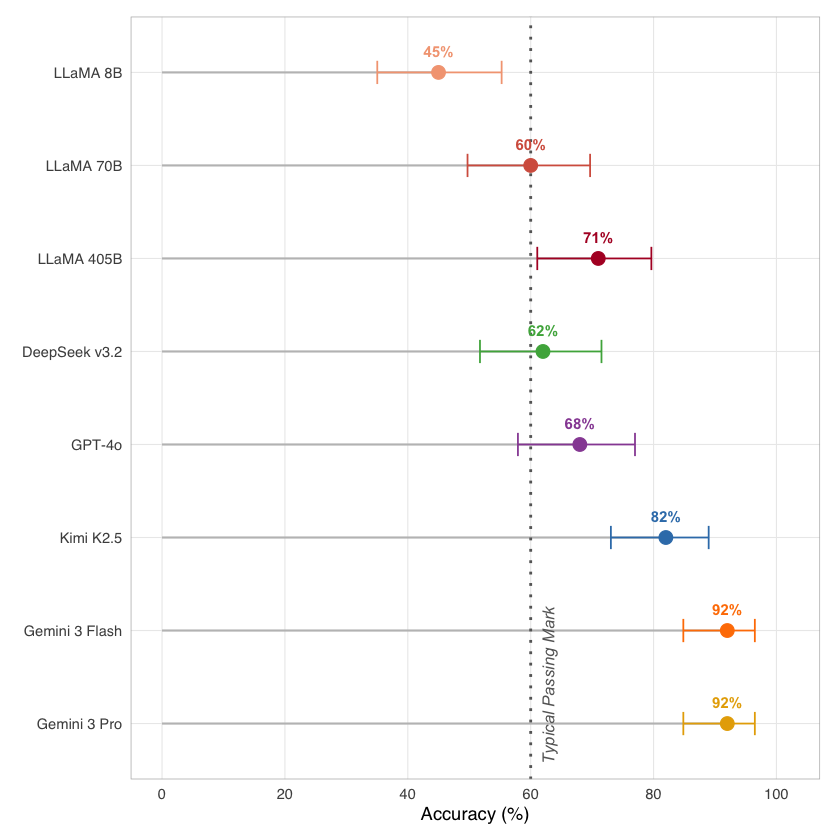

In [5]:
accuracy_overall <- df |>
  group_by(model, model_label) |>
  summarise(
    n = n(),
    n_correct = sum(correct_deterministic),
    accuracy = mean(correct_deterministic) * 100,
    .groups = "drop"
  ) |>
  mutate(
    ci = map2(n_correct, n, ~ suppressWarnings(binom.test(.x, .y)$conf.int * 100)),
    ci_lo = map_dbl(ci, 1),
    ci_hi = map_dbl(ci, 2),
    model_label = factor(model_label, levels = rev(model_labels[model_order]))
  ) |>
  select(-ci)

p_fig2 <- ggplot(accuracy_overall, aes(x = accuracy, y = model_label, colour = model)) +
  geom_segment(aes(x = 0, xend = accuracy, yend = model_label), linewidth = 0.6, colour = "grey75") +
  geom_errorbarh(aes(xmin = ci_lo, xmax = ci_hi), height = 0.25, linewidth = 0.5) +
  geom_vline(xintercept = 60, linetype = "dotted", colour = "grey40", linewidth = 0.8) +
  annotate("text", x = 61, y = -Inf, label = "Typical Passing Mark",
           angle = 90, vjust = 1.5, hjust = -0.1, size = 3.5,
           colour = "grey40", fontface = "italic") +
  geom_point(size = 3.5) +
  geom_text(aes(label = sprintf("%.0f%%", accuracy)), vjust = -1.5, hjust = 0.5,
            size = 3.2, fontface = "bold", show.legend = FALSE) +
  scale_colour_manual(values = model_colours, guide = "none") +
  scale_x_continuous(limits = c(0, 102), breaks = seq(0, 100, 20)) +
  labs(x = "Accuracy (%)", y = NULL)

ggsave(file.path(output_dir, "figure2.png"), p_fig2, width = 9, height = 5, dpi = 300, bg = "white")
p_fig2



## 6. Calibration and Discrimination Metrics



In [6]:
set.seed(42)

metrics <- map_dfr(model_order, function(m) {
  sub <- df |> filter(model == m)
  n_correct <- sum(sub$correct_deterministic)
  n_total <- nrow(sub)
  acc_ci <- ci_accuracy(n_correct, n_total)

  row <- tibble(
    model = model_labels[m],
    accuracy = mean(sub$correct_deterministic) * 100,
    accuracy_lo = acc_ci$lo,
    accuracy_hi = acc_ci$hi
  )

  for (method_name in names(confidence_methods)) {
    col <- confidence_methods[[method_name]]
    valid <- sub |> filter(!is.na(.data[[col]]))
    y <- as.numeric(valid$correct_deterministic)
    c_val <- valid[[col]]
    suffix <- str_replace_all(method_name, "[- ]", "_")

    ece_ci <- ci_ece(y, c_val)
    auc_ci <- ci_auroc(y, c_val)

    row[[paste0("ECE_", suffix)]] <- compute_ece(y, c_val)
    row[[paste0("ECE_lo_", suffix)]] <- ece_ci$lo
    row[[paste0("ECE_hi_", suffix)]] <- ece_ci$hi
    row[[paste0("AUROC_", suffix)]] <- compute_auroc(y, c_val)
    row[[paste0("AUROC_lo_", suffix)]] <- auc_ci$lo
    row[[paste0("AUROC_hi_", suffix)]] <- auc_ci$hi
    row[[paste0("mean_conf_", suffix)]] <- mean(c_val)
  }

  row
})

write_csv(metrics, file.path(output_dir, "table1_metrics_numeric.csv"))



## 7. Figure 3: Mean Confidence Versus Accuracy



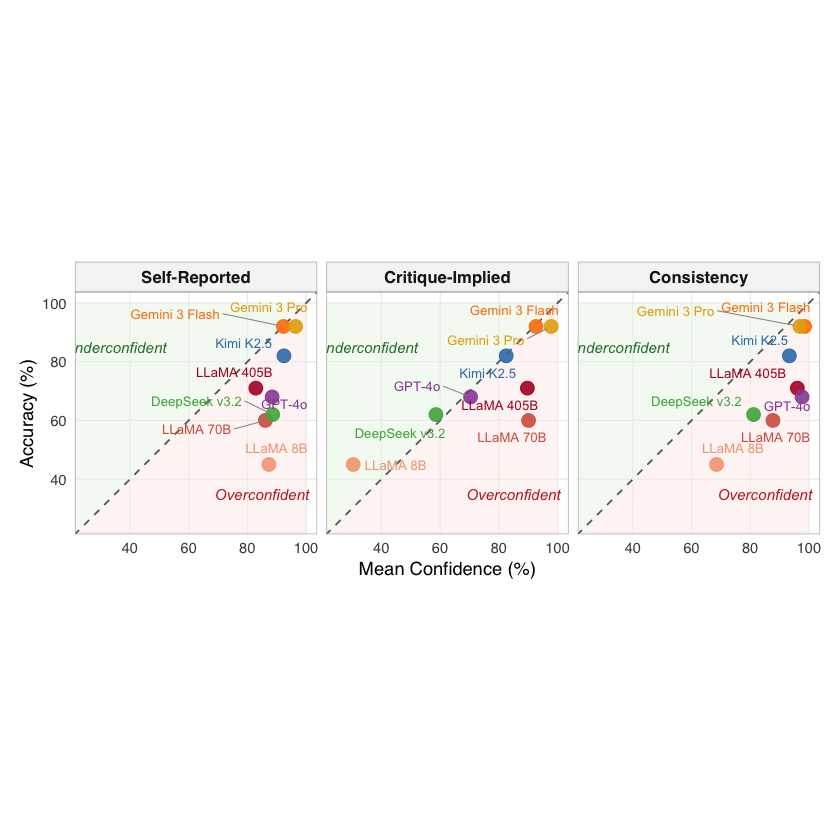

In [7]:
overconfidence_data <- metrics |>
  select(model, accuracy, starts_with("mean_conf")) |>
  pivot_longer(starts_with("mean_conf"), names_to = "method", values_to = "mean_conf") |>
  mutate(
    method = str_remove(method, "mean_conf_"),
    method = recode(method,
      Self_Reported = "Self-Reported",
      Critique_Implied = "Critique-Implied",
      Consistency = "Consistency"
    ),
    method = factor(method, levels = names(confidence_methods)),
    gap = mean_conf - accuracy
  )

p_fig3 <- ggplot(overconfidence_data, aes(x = mean_conf, y = accuracy)) +
  annotate("polygon", x = c(0, 100, 100), y = c(0, 0, 100), fill = "#FDECEA", alpha = 0.5) +
  annotate("polygon", x = c(0, 0, 100), y = c(0, 100, 100), fill = "#E8F5E9", alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey40", linewidth = 0.5) +
  geom_point(aes(colour = model), size = 3.5, alpha = 0.9) +
  geom_text_repel(aes(label = model, colour = model), size = 2.8, max.overlaps = 20,
                  segment.colour = "grey60", segment.size = 0.3,
                  box.padding = 0.4, point.padding = 0.3,
                  seed = 42, show.legend = FALSE) +
  facet_wrap(~ method) +
  annotate("text", x = 85, y = 35, label = "Overconfident",
           size = 3.2, colour = "#C62828", fontface = "italic") +
  annotate("text", x = 35, y = 85, label = "Underconfident",
           size = 3.2, colour = "#2E7D32", fontface = "italic") +
  scale_colour_manual(values = model_label_colours) +
  coord_equal(xlim = c(25, 100), ylim = c(25, 100)) +
  theme(legend.position = "none") +
  labs(x = "Mean Confidence (%)", y = "Accuracy (%)")

write_csv(overconfidence_data, file.path(output_dir, "mean_confidence_accuracy.csv"))
ggsave(file.path(output_dir, "figure3.png"), p_fig3, width = 16, height = 6, dpi = 300, bg = "white")
p_fig3



## 8. Figure 4: Consistency-Based Selective Abstention



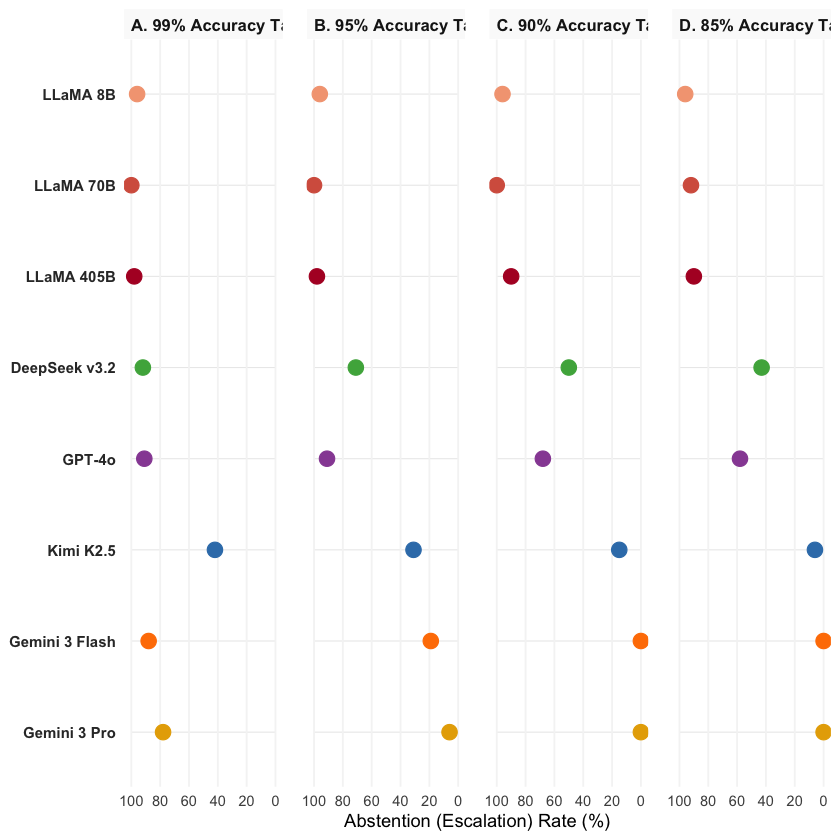

In [8]:
abstention_at_target <- function(sub, conf_col, target) {
  sub <- sub |>
    filter(!is.na(.data[[conf_col]])) |>
    arrange(desc(.data[[conf_col]])) |>
    mutate(answered = row_number(), cum_acc = cummean(correct_deterministic))

  kept <- sub |> filter(cum_acc >= target)
  if (nrow(kept) == 0) {
    return(tibble(actual_acc = NA_real_, min_conf = NA_real_, answered_pct = 0, abstain_pct = 100))
  }

  cut <- kept |> slice_tail(n = 1)
  tibble(
    actual_acc = cut$cum_acc * 100,
    min_conf = cut[[conf_col]],
    answered_pct = (cut$answered / nrow(sub)) * 100,
    abstain_pct = (1 - cut$answered / nrow(sub)) * 100
  )
}

target_levels <- c(0.99, 0.95, 0.90, 0.85)

abstention_grid <- map_dfr(target_levels, function(target) {
  map_dfr(names(confidence_methods), function(method_name) {
    col <- confidence_methods[[method_name]]
    map_dfr(model_order, function(m) {
      sub <- df |> filter(model == m)
      result <- abstention_at_target(sub, col, target)
      tibble(
        model = m,
        model_label = model_labels[m],
        method = method_name,
        target_acc = target * 100,
        result
      )
    })
  })
}) |>
  mutate(method = factor(method, levels = names(confidence_methods)))

figure4_data <- abstention_grid |>
  filter(method == "Consistency") |>
  arrange(desc(target_acc)) |>
  mutate(
    panel_letter = LETTERS[match(target_acc, sort(unique(target_acc), decreasing = TRUE))],
    target_facet = paste0(panel_letter, ". ", target_acc, "% Accuracy Target"),
    target_facet = fct_inorder(target_facet),
    model_label = factor(model_label, levels = rev(model_labels[model_order]))
  )

p_fig4 <- ggplot(figure4_data, aes(x = abstain_pct, y = model_label, colour = model)) +
  geom_segment(aes(x = 0, xend = 100, y = model_label, yend = model_label),
               linewidth = 0.3, colour = "grey92", inherit.aes = FALSE) +
  geom_vline(xintercept = seq(0, 100, 20), linetype = "solid", colour = "grey96") +
  geom_point(size = 4) +
  scale_x_reverse(limits = c(100, 0), breaks = seq(0, 100, 20), expand = c(0.05, 0.05)) +
  scale_colour_manual(values = model_colours, guide = "none") +
  facet_wrap(~ target_facet, ncol = 4) +
  labs(x = "Abstention (Escalation) Rate (%)", y = NULL) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid = element_blank(),
    strip.text = element_text(face = "bold", size = 10, hjust = 0),
    strip.background = element_rect(fill = "grey98", colour = NA),
    axis.text.y = element_text(face = "bold", size = 9, colour = "grey20"),
    panel.spacing = unit(1, "lines")
  )

write_csv(abstention_grid, file.path(output_dir, "abstention_rates_all_methods.csv"))
write_csv(figure4_data, file.path(output_dir, "figure4_consistency_abstention.csv"))
ggsave(file.path(output_dir, "figure4.png"), p_fig4, width = 11, height = 4, dpi = 300, bg = "white")
p_fig4



## 9. Table 1: Accuracy, Calibration, and Discrimination



In [9]:
table1_formatted <- metrics |>
  transmute(
    Model = model,
    `Accuracy (%)` = fmt1(accuracy, accuracy_lo, accuracy_hi),
    `Self ECE` = fmt1(ECE_Self_Reported, ECE_lo_Self_Reported, ECE_hi_Self_Reported),
    `Critique ECE` = fmt1(ECE_Critique_Implied, ECE_lo_Critique_Implied, ECE_hi_Critique_Implied),
    `Consistency ECE` = fmt1(ECE_Consistency, ECE_lo_Consistency, ECE_hi_Consistency),
    `Self AUROC` = fmt3(AUROC_Self_Reported, AUROC_lo_Self_Reported, AUROC_hi_Self_Reported),
    `Critique AUROC` = fmt3(AUROC_Critique_Implied, AUROC_lo_Critique_Implied, AUROC_hi_Critique_Implied),
    `Consistency AUROC` = fmt3(AUROC_Consistency, AUROC_lo_Consistency, AUROC_hi_Consistency)
  )

write_csv(table1_formatted, file.path(output_dir, "table1_metrics_formatted.csv"))

table1_formatted |>
  kable(
    align = c("l", rep("r", ncol(table1_formatted) - 1)),
    caption = paste0(
      "Table 1. Language model accuracy, calibration, and discrimination. ",
      "Accuracy CI: Clopper-Pearson exact binomial; ECE CI: percentile bootstrap (B = 2000); ",
      "AUROC CI: DeLong via pROC::ci.auc."
    )
  )





Table: Table 1. Language model accuracy, calibration, and discrimination. Accuracy CI: Clopper-Pearson exact binomial; ECE CI: percentile bootstrap (B = 2000); AUROC CI: DeLong via pROC::ci.auc.

|Model          |     Accuracy (%)|         Self ECE|     Critique ECE|  Consistency ECE|          Self AUROC|      Critique AUROC|   Consistency AUROC|
|:--------------|----------------:|----------------:|----------------:|----------------:|-------------------:|-------------------:|-------------------:|
|LLaMA 8B       | 45.0 (35.0-55.3)| 42.3 (33.1-51.9)| 30.6 (20.8-41.0)| 26.1 (19.8-36.1)| 0.470 (0.364-0.576)| 0.521 (0.430-0.612)| 0.697 (0.595-0.799)|
|LLaMA 70B      | 60.0 (49.7-69.7)| 26.9 (17.7-36.7)| 35.3 (25.8-45.4)| 29.3 (21.9-39.0)| 0.555 (0.452-0.659)| 0.555 (0.472-0.638)| 0.680 (0.585-0.776)|
|LLaMA 405B     | 71.0 (61.1-79.6)|  11.8 (3.7-20.9)| 23.5 (14.8-32.5)| 25.0 (17.4-34.2)| 0.614 (0.528-0.701)| 0.571 (0.456-0.686)| 0.640 (0.539-0.741)|
|DeepSeek v3.2  | 62.0 (51.7-71.5)| 2

## 10. Supplementary Table 1: Accuracy by Question Type



In [10]:
model_meta <- tibble(model = model_order, Model = unname(model_labels[model_order])) |>
  mutate(
    Family = case_when(
      str_detect(model, "meta-llama") ~ "LLaMA",
      str_detect(model, "google_gemini") ~ "Gemini",
      str_detect(model, "openai") ~ "OpenAI",
      str_detect(model, "deepseek") ~ "DeepSeek",
      str_detect(model, "moonshotai") ~ "MoonshotAI",
      TRUE ~ "Other"
    ),
    Type = case_when(
      str_detect(model, "8b") ~ "8B",
      str_detect(model, "70b") ~ "70B",
      str_detect(model, "405b") ~ "405B",
      str_detect(model, "flash") ~ "Flash",
      str_detect(model, "pro") ~ "Pro",
      str_detect(model, "gpt-4o") ~ "GPT-4o",
      str_detect(model, "v3.2") ~ "v3.2",
      str_detect(model, "k2.5") ~ "K2.5",
      TRUE ~ "-"
    )
  )

acc_block <- function(data, label) {
  data |>
    group_by(model) |>
    summarise(n_total = n(), n_correct = sum(correct_deterministic), .groups = "drop") |>
    mutate(!!label := map2_chr(n_correct, n_total, fmt_acc_ci)) |>
    select(model, all_of(label))
}

supplementary_table1 <- model_meta |>
  left_join(acc_block(df, "Overall (%)"), by = "model") |>
  left_join(acc_block(filter(df, QuType == "text"), "Text (%)"), by = "model") |>
  left_join(acc_block(filter(df, QuType == "image"), "Image (%)"), by = "model") |>
  select(Model, Family, Type, `Overall (%)`, `Text (%)`, `Image (%)`)

write_csv(supplementary_table1, file.path(output_dir, "supplementary_table1_accuracy.csv"))

supplementary_table1 |>
  kable(
    align = c("l", "l", "l", "c", "c", "c"),
    caption = "Supplementary Table 1. Deterministic accuracy with 95% Clopper-Pearson confidence intervals."
  )





Table: Supplementary Table 1. Deterministic accuracy with 95% Clopper-Pearson confidence intervals.

|Model          |Family     |Type   |   Overall (%)    |     Text (%)     |     Image (%)      |
|:--------------|:----------|:------|:----------------:|:----------------:|:------------------:|
|LLaMA 8B       |LLaMA      |8B     | 45.0 (35.0-55.3) | 47.3 (36.9-57.9) |  14.3 (0.4-57.9)   |
|LLaMA 70B      |LLaMA      |70B    | 60.0 (49.7-69.7) | 62.4 (51.7-72.2) |  28.6 (3.7-71.0)   |
|LLaMA 405B     |LLaMA      |405B   | 71.0 (61.1-79.6) | 73.1 (62.9-81.8) |  42.9 (9.9-81.6)   |
|DeepSeek v3.2  |DeepSeek   |v3.2   | 62.0 (51.7-71.5) | 63.4 (52.8-73.2) |  42.9 (9.9-81.6)   |
|GPT-4o         |OpenAI     |GPT-4o | 68.0 (57.9-77.0) | 69.9 (59.5-79.0) |  42.9 (9.9-81.6)   |
|Kimi K2.5      |MoonshotAI |K2.5   | 82.0 (73.1-89.0) | 82.8 (73.6-89.8) |  71.4 (29.0-96.3)  |
|Gemini 3 Flash |Gemini     |Flash  | 92.0 (84.8-96.5) | 91.4 (83.8-96.2) | 100.0 (59.0-100.0) |
|Gemini 3 Pro   |Gemini 

## 11. Statistical Comparisons and Reproducibility



In [11]:
ece_long <- metrics |>
  select(model, ECE_Self_Reported, ECE_Critique_Implied, ECE_Consistency) |>
  pivot_longer(-model, names_to = "method", values_to = "ECE") |>
  mutate(
    method = recode(method,
      ECE_Self_Reported = "Self-Reported",
      ECE_Critique_Implied = "Critique-Implied",
      ECE_Consistency = "Consistency"
    )
  )

ece_summary <- ece_long |>
  group_by(method) |>
  summarise(mean_ece = mean(ECE), sd_ece = sd(ECE), .groups = "drop")

ece_friedman <- friedman.test(
  as.matrix(metrics |> select(ECE_Self_Reported, ECE_Critique_Implied, ECE_Consistency))
)

pairwise_delong <- function(method_1, method_2) {
  col_1 <- confidence_methods[[method_1]]
  col_2 <- confidence_methods[[method_2]]
  valid <- df |>
    filter(!is.na(.data[[col_1]]), !is.na(.data[[col_2]]), !is.na(correct_deterministic))

  roc_1 <- roc(valid$correct_deterministic, valid[[col_1]], quiet = TRUE, direction = "<")
  roc_2 <- roc(valid$correct_deterministic, valid[[col_2]], quiet = TRUE, direction = "<")

  tibble(
    comparison = paste(method_1, "vs", method_2),
    method_1_auroc = as.numeric(auc(roc_1)),
    method_2_auroc = as.numeric(auc(roc_2)),
    p_value = roc.test(roc_1, roc_2, method = "delong")$p.value
  )
}

delong_results <- bind_rows(
  pairwise_delong("Self-Reported", "Critique-Implied"),
  pairwise_delong("Self-Reported", "Consistency"),
  pairwise_delong("Critique-Implied", "Consistency")
)

method_comparisons <- bind_rows(
  ece_summary |> mutate(test = "ECE mean across models", statistic = NA_real_, p_value = NA_real_),
  tibble(
    method = "All methods",
    mean_ece = NA_real_,
    sd_ece = NA_real_,
    test = "Friedman test for ECE",
    statistic = unname(ece_friedman$statistic),
    p_value = ece_friedman$p.value
  )
)

write_csv(ece_summary, file.path(output_dir, "ece_method_summary.csv"))
write_csv(delong_results, file.path(output_dir, "pooled_auroc_delong_tests.csv"))
write_csv(method_comparisons, file.path(output_dir, "method_comparisons.csv"))
writeLines(capture.output(sessionInfo()), file.path(output_dir, "session_info.txt"))

ece_summary
delong_results
sessionInfo()


method,mean_ece,sd_ece
<chr>,<dbl>,<dbl>
Consistency,20.02500,9.231739
Critique-Implied,17.80625,11.564912
Self-Reported,18.54125,13.008724


comparison,method_1_auroc,method_2_auroc,p_value
<chr>,<dbl>,<dbl>,<dbl>
Self-Reported vs Critique-Implied,0.6873888,0.6993390,0.66150378
Self-Reported vs Consistency,0.6873888,0.7393801,0.04790743
Critique-Implied vs Consistency,0.6993390,0.7393801,0.09968080


R version 4.3.1 (2023-06-16)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS 26.3.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.11.0

locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: Europe/London
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.5   knitr_1.50      pROC_1.18.5     lubridate_1.9.3
 [5] forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4     purrr_1.0.4    
 [9] readr_2.1.5     tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] utf8_1.2.4         generics_0.1.3     stringi_1.8.4      hms_1.1.3         
 [5] digest_0.6.36      magrittr_2.0.3     evaluate_0.24.0    grid_4.3.1        
 [9] t